# SIMULATION OF EARTH-MOON-SUN THREE BODY PROBLEM

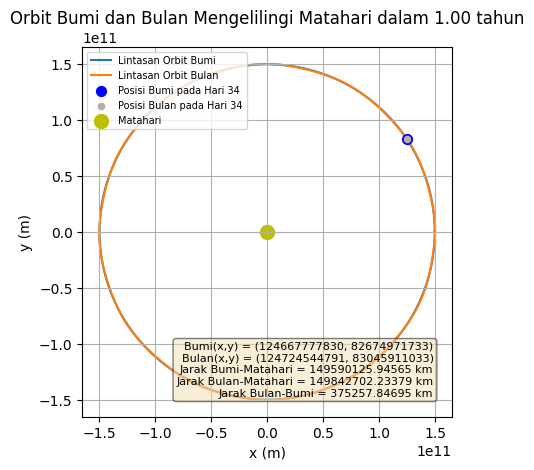

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Konstanta
G = 6.67430e-11  # konstanta gravitasi
M_sun = 1.989e30  # massa Matahari (kg)
M_earth = 5.972e24  # massa Bumi (kg)
M_moon = 7.342e22  # massa Bulan (kg)

# Kondisi awal Bumi
r_bumi = np.array([1.496e11, 0, 0])  # Posisi awal (jarak rata-rata Bumi ke Matahari dalam meter)
v_bumi = np.array([0, 29783, 0])  # Kecepatan awal (kecepatan orbit Bumi dalam m/s)
dt = 60 * 60  # Langkah waktu dalam detik (1 jam)
steps = 1000

# Kondisi awal Bulan
r_bulan = r_bumi + np.array([3.844e8, 0, 0])  # Posisi awal (jarak Bumi ke Bulan dalam meter)
v_bulan = v_bumi + np.array([0, 1022, 0])  # Kecepatan awal (kecepatan orbit Bulan dalam m/s)

# Fungsi percepatan
def dv_dt_earth(r_earth, M):
    r_magnitude = np.linalg.norm(r_earth)
    return -G * (M / r_magnitude**3) * r_earth

# Fungsi percepatan Bulan
def dv_dt_moon(r_moon, r_earth, M_sun, M_earth):
    r_moon_sun = np.linalg.norm(r_moon)
    r_moon_earth = np.linalg.norm(r_moon - r_earth)
    a_moon_sun = -G * M_sun / r_moon_sun**3 * r_moon
    a_moon_earth = -G * M_earth / r_moon_earth**3 * (r_moon - r_earth)
    return a_moon_sun + a_moon_earth

# Fungsi PDB metode Runge-Kutta Orde 4 (RK4)
def rk4(r, v, dt, dv_dt_func, *args):
    a = dv_dt_func(r, *args)
    k1_v = a
    k1_r = v
    
    a = dv_dt_func(r + k1_r * dt / 2, *args)
    k2_v = a
    k2_r = v + k1_v * dt / 2
    
    a = dv_dt_func(r + k2_r * dt / 2, *args)
    k3_v = a
    k3_r = v + k2_v * dt / 2
    
    a = dv_dt_func(r + k3_r * dt, *args)
    k4_v = a
    k4_r = v + k3_v * dt
    
    r_next = r + (k1_r + 2*k2_r + 2*k3_r + k4_r) * dt / 6
    v_next = v + (k1_v + 2*k2_v + 2*k3_v + k4_v) * dt / 6
    
    return r_next, v_next

# Fungsi interpolasi Lagrange
def interpolasi_lagrange(x, y, xp):
    yp = 0
    n = len(x)
    for i in range(n):
        p = 1
        for j in range(n):
            if i != j:
                p *= (xp - x[j]) / (x[i] - x[j])
        yp += p * y[i]
    return yp

# Fungsi untuk melakukan simulasi
def orbit(tahun):
    interval = int(365.25 * 24 * 3600 / dt)
    n_step = int(tahun * interval)
    
    # List awal lintasan
    lintasan_bumi = []
    lintasan_bulan = []
    
    r_bumi = np.array([1.496e11, 0, 0])
    v_bumi = np.array([0, 29783, 0])
    
    r_bulan = r_bumi + np.array([3.844e8, 0, 0])
    v_bulan = v_bumi + np.array([0, 1022, 0])
    
    for _ in range(n_step):
        r_bumi, v_bumi = rk4(r_bumi, v_bumi, dt, dv_dt_earth, M_sun)
        lintasan_bumi.append(r_bumi)
        
        r_bulan, v_bulan = rk4(r_bulan, v_bulan, dt, dv_dt_moon, r_bumi, M_sun, M_earth)
        lintasan_bulan.append(r_bulan)
    
    lintasan_bumi = np.array(lintasan_bumi)
    lintasan_bulan = np.array(lintasan_bulan)
    
    return lintasan_bumi, lintasan_bulan

# Fungsi untuk melakukan interpolasi posisi
def posisi(lintasan_bumi, lintasan_bulan, hari):
    t_interpolasi = hari * 24 * 3600  # Konversi hari ke detik

    # Titik interpolasi
    points = 3  # Jumlah titik yang digunakan untuk interpolasi
    start_index = max(0, int(t_interpolasi // dt) - points // 2)
    end_index = min(len(lintasan_bumi), start_index + points)
    selected_times = np.arange(start_index, end_index) * dt
    earth_trajectory = lintasan_bumi[start_index:end_index]
    moon_trajectory = lintasan_bulan[start_index:end_index]

    # Hitung posisi interpolasi Bumi
    r_bumi_int_x = interpolasi_lagrange(selected_times, earth_trajectory[:, 0], t_interpolasi)
    r_bumi_int_y = interpolasi_lagrange(selected_times, earth_trajectory[:, 1], t_interpolasi)
    r_bumi_int = np.array([r_bumi_int_x, r_bumi_int_y])

    # Hitung posisi interpolasi Bulan
    r_bulan_int_x = interpolasi_lagrange(selected_times, moon_trajectory[:, 0], t_interpolasi)
    r_bulan_int_y = interpolasi_lagrange(selected_times, moon_trajectory[:, 1], t_interpolasi)
    r_bulan_int = np.array([r_bulan_int_x, r_bulan_int_y])

    return r_bumi_int, r_bulan_int

# Fungsi untuk menampilkan jarak
def jarak(r_bumi_int, r_bulan_int, satuan):
    r_bumi = np.linalg.norm(r_bumi_int)
    r_bulan_matahari = np.linalg.norm(r_bulan_int)
    r_bulan_bumi = np.linalg.norm(r_bulan_int - r_bumi_int)
    
    if satuan == "km":
        r_bumi /= 1000
        r_bulan_matahari /= 1000
        r_bulan_bumi /= 1000
    elif satuan == "AU":
        r_bumi /= 1.496e11
        r_bulan_matahari /= 1.496e11
        r_bulan_bumi /= 1.496e11
    
    return r_bumi, r_bulan_matahari, r_bulan_bumi

# Fungsi untuk plotting lintasan
def plot(lintasan_bumi, lintasan_bulan, r_bumi_int, r_bulan_int, hari, tahun, satuan, bumi_matahari, bulan_matahari, bulan_bumi):
    plt.plot(lintasan_bumi[:, 0], lintasan_bumi[:, 1], label='Lintasan Orbit Bumi', zorder=1)
    plt.plot(lintasan_bulan[:, 0], lintasan_bulan[:, 1], label='Lintasan Orbit Bulan', zorder=1)
    plt.scatter(r_bumi_int[0], r_bumi_int[1], color='b', s=50, label=f'Posisi Bumi pada Hari {hari}', zorder=2)
    plt.scatter(r_bulan_int[0], r_bulan_int[1], color='#B8AEA3', s=20, label=f'Posisi Bulan pada Hari {hari}', zorder=2)
    plt.scatter(0, 0, color='y', s=100, label='Matahari')  # Matahari di pusat
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title('Orbit Bumi dan Bulan Mengelilingi Matahari dalam %.2f tahun' % tahun)
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    textstr = '\n'.join((
        'Bumi(x,y) = (%d, %d)' % (r_bumi_int[0], r_bumi_int[1]),
        'Bulan(x,y) = (%d, %d)' % (r_bulan_int[0], r_bulan_int[1]),
        f'Jarak Bumi-Matahari = {bumi_matahari:.5f} {satuan}',
        f'Jarak Bulan-Matahari = {bulan_matahari:.5f} {satuan}',
        f'Jarak Bulan-Bumi = {bulan_bumi:.5f} {satuan}'
    ))
    plt.gca().text(0.95, 0.05, textstr, transform=plt.gca().transAxes, fontsize=8,
                   verticalalignment='bottom', horizontalalignment='right', bbox=props)
    
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(loc='upper left', prop={'size': 7})
    plt.grid()
    plt.show()

# Bagian utama program
while True:
    try:
        tahun = float(input("Masukkan jumlah tahun: "))
        break
    except ValueError:
        print("Masukkan angka dengan benar.")

# Jalankan simulasi
lintasan_bumi, lintasan_bulan = orbit(tahun)

# Tampilkan hasil awal
while True:
    try:
        hari = int(input("Masukkan hari: "))
        if 0 <= hari <= tahun * 365:
            break
        else:
            print("Masukkan hari antara 0 dan %d" % (tahun * 365))
    except ValueError:
        print("Masukkan angka dengan benar.")

while True:
    try:
        mode = int(input("Pilih satuan: \n 1. meter \n 2. kilometer \n 3. Satuan astronomi (AU) \n Masukkan pilihan: "))
        if mode == 1:
            satuan = "m"
            break
        elif mode == 2:
            satuan = "km"
            break
        elif mode == 3:
            satuan = "AU"
            break
    except ValueError:
        print("Masukkan opsi yang tersedia.")
r_bumi_int, r_bulan_int = posisi(lintasan_bumi, lintasan_bulan, hari)
bumi_matahari, bulan_matahari, bulan_bumi = jarak(r_bumi_int, r_bulan_int, satuan)

plot(lintasan_bumi, lintasan_bulan, r_bumi_int, r_bulan_int, hari, tahun, satuan, bumi_matahari, bulan_matahari, bulan_bumi)
#anim(lintasan_bumi, lintasan_bulan, r_bumi_int, r_bulan_int, hari, tahun, satuan, bumi_matahari, bulan_matahari, bulan_bumi)
# Tampilkan posisi pada hari lain tanpa simulasi ulang
while True:
    try:
        hari = int(input("Masukkan hari lain (atau -1 untuk keluar): "))
        if hari == -1:
            break
        if 0 <= hari <= tahun * 365:
            r_bumi_int, r_bulan_int = posisi(lintasan_bumi, lintasan_bulan, hari)
            bumi_matahari, bulan_matahari, bulan_bumi = jarak(r_bumi_int, r_bulan_int, satuan)
            plot(lintasan_bumi, lintasan_bulan, r_bumi_int, r_bulan_int, hari, tahun, satuan, bumi_matahari, bulan_matahari, bulan_bumi)
        else:
            print("Masukkan hari antara 0 dan %d" % (tahun * 365))
    except ValueError:
        print("Masukkan angka dengan benar.")